In [1]:
!pip3 install transkun


import os
from google.colab import files
import zipfile


def removeExtension(file):
    return ".".join(os.path.basename(file).split('.')[:-1])

def transcribe(file, outfolder='.'):
  print(file)

  path = os.path.join(outfolder, removeExtension(file)+".mid")
  os.system('transkun "%s" "%s" --device cuda'%(file,path))
  return path

uploaded = files.upload()
if len(uploaded) >= 2:
    newZip = zipfile.ZipFile("transcribe.zip", 'w')
    for fn in uploaded.keys():
        newZip.write(transcribe(fn, "."), compress_type=zipfile.ZIP_DEFLATED)
    newZip.close()
    files.download("transcribe.zip")
else:
    for fn in uploaded.keys():
      files.download(transcribe(fn, "."))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 35.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.8 MB/s eta 0:00:00
  Created wheel for pretty-midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=acfa3b8b19aa6fe3aebf9df19884e08f28265f8b8b56ade5886f12b042ad9737
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
  Created wheel 

Saving c-major-scale.mp3 to c-major-scale.mp3
c-major-scale.mp3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Інструмент: Piano (program 0)

Список усіх нот у MIDI:


,start_sec,end_sec,duration_sec,midi_pitch,note_name,velocity
0,0.004,0.405,0.402,48,C3,91
1,0.390,0.800,0.410,50,D3,92
2,0.781,1.174,0.393,52,E3,93
3,1.173,1.583,0.410,53,F3,93
4,1.564,1.965,0.401,55,G3,94
5,1.956,2.355,0.399,57,A3,90
6,2.347,2.749,0.402,59,B3,92
7,2.735,3.145,0.410,60,C4,93
8,3.127,3.517,0.391,59,B3,92
9,3.517,3.911,0.394,57,A3,91



Унікальні ноти:
['C3' 'D3' 'E3' 'F3' 'G3' 'A3' 'B3' 'C4']

Загальна кількість нот: 15
Тривалість треку: 5.87 сек


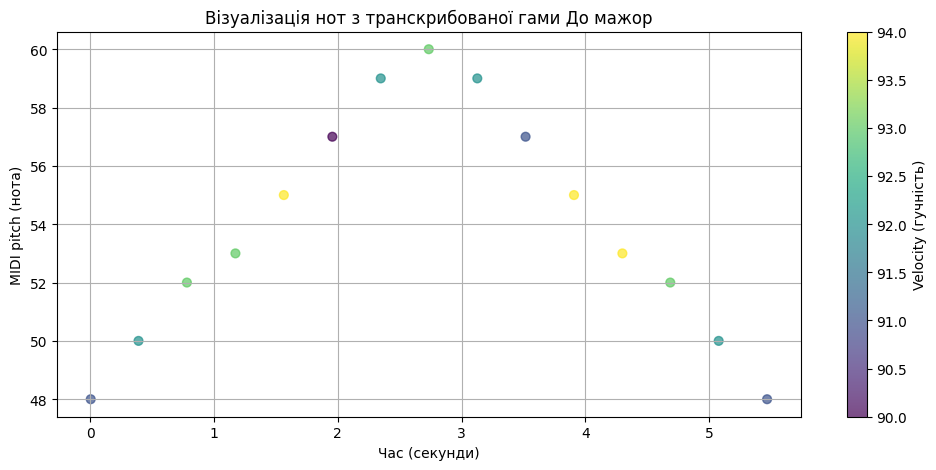

In [2]:
!pip install pretty-midi pandas -q

import pretty_midi
import pandas as pd
import os

midi_file = "c-major-scale.mid"

if not os.path.exists(midi_file):
    print("MIDI-файл не знайдено. Перевір назву або завантаж ще раз.")
else:
    midi = pretty_midi.PrettyMIDI(midi_file)

    notes_list = []
    for instrument in midi.instruments:
        print(f"Інструмент: {instrument.name or 'Piano'} (program {instrument.program})")
        for note in instrument.notes:
            notes_list.append({
                'start_sec': round(note.start, 3),
                'end_sec': round(note.end, 3),
                'duration_sec': round(note.end - note.start, 3),
                'midi_pitch': note.pitch,
                'note_name': pretty_midi.note_number_to_name(note.pitch),
                'velocity': note.velocity
            })

    df = pd.DataFrame(notes_list)

    print("\nСписок усіх нот у MIDI:")
    display(df)

    print("\nУнікальні ноти:")
    print(df['note_name'].unique())

    print(f"\nЗагальна кількість нот: {len(df)}")
    print(f"Тривалість треку: {midi.get_end_time():.2f} сек")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 5))
    plt.scatter(df['start_sec'], df['midi_pitch'], s=40, c=df['velocity'], cmap='viridis', alpha=0.7)
    plt.colorbar(label='Velocity (гучність)')
    plt.xlabel('Час (секунди)')
    plt.ylabel('MIDI pitch (нота)')
    plt.title('Візуалізація нот з транскрибованої гами До мажор')
    plt.grid(True)
    plt.show()
